# Exploration des données

In [5]:
import pandas
import numpy as np
import matplotlib.pyplot as plt

# Chargement du fichier CSV avec les bons paramètres
dataframe=pandas.read_csv("/home/jmaubian/SDD/Hackathon/X_train.csv",sep=';')
dataframe.columns

Index(['id', 'album', 'artist', 'artists', 'aspect_ratio', 'channel',
       'description', 'video_duration', 'format', 'release_year', 'track',
       'uploader', 'filepath', 'download_timing', 'uploader_short', 'vid',
       'uid'],
      dtype='object')

In [2]:
dataframe.head()

,id,album,artist,artists,aspect_ratio,channel,description,video_duration,format,release_year,track,uploader,filepath,download_timing,uploader_short,vid,uid
0,7602656035161050390,NaN,Urhov Bogdan,['Urhov Bogdan'],0.56,Davos Klosters,you dream you 🥹 #davosklosters #skiing #mounta...,13,1080x1920,2026,оригинальный звук,davosklosters,downloads/USER_davosklosters/VIDEO_76026560351...,2026-02-12 09:29:25,davos,VIDEO_7602656035161050390,USER_davosklosters
1,7590718903144287510,NaN,LykTraffx,['LykTraffx'],0.56,Davos Klosters,already missing this again 🥹 #spenglercup #dav...,12,1080x1920,2026,оригинальный звук,davosklosters,downloads/USER_davosklosters/VIDEO_75907189031...,2026-02-12 09:29:25,davos,VIDEO_7590718903144287510,USER_davosklosters
2,7571821778746592534,NaN,ALTÉGO,['ALTÉGO'],0.56,Davos Klosters,how??!!!🥹🥹 #davosklosters #skiing #ski #season...,13,1080x1920,2025,THE FATE OF OPHELIA X MIDNIGHT CITY,davosklosters,downloads/USER_davosklosters/VIDEO_75718217787...,2026-02-12 09:29:25,davos,VIDEO_7571821778746592534,USER_davosklosters
3,7569927329154190614,NaN,Raye,['Raye'],0.56,Davos Klosters,We're back on snow!🥹🎿 #davosklosters #seasonop...,7,1080x1920,2025,original sound,davosklosters,downloads/USER_davosklosters/VIDEO_75699273291...,2026-02-12 09:29:25,davos,VIDEO_7569927329154190614,USER_davosklosters
4,7566270741134462230,NaN,músicas e traduções,['músicas e traduções'],0.56,Davos Klosters,"Somebody send help, pls. 🥶 #davos #firstsnow #...",8,1080x1920,2025,som original,davosklosters,downloads/USER_davosklosters/VIDEO_75662707411...,2026-02-12 09:29:25,davos,VIDEO_7566270741134462230,USER_davosklosters


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Chargement des données
X_train=pd.read_csv("/home/jmaubian/SDD/Hackathon/X_train.csv",sep=';')
y_train=pd.read_csv("/home/jmaubian/SDD/Hackathon/y_train.csv",sep=';')
X_test=pd.read_csv("/home/jmaubian/SDD/Hackathon/X_test.csv",sep=';')

df = X_train.merge(y_train, left_on='id', right_on='ID')

print(df.shape)
print(df.dtypes)
print(df.isnull().sum().sort_values(ascending=False))

(1348, 19)
id                   int64
album               object
artist              object
artists             object
aspect_ratio       float64
channel             object
description         object
video_duration       int64
format              object
release_year         int64
track               object
uploader            object
filepath            object
download_timing     object
uploader_short      object
vid                 object
uid                 object
ID                   int64
popularity         float64
dtype: object
album              973
artist              31
artists             31
track               26
description          5
id                   0
aspect_ratio         0
channel              0
video_duration       0
format               0
release_year         0
uploader             0
filepath             0
download_timing      0
uploader_short       0
vid                  0
uid                  0
ID                   0
popularity           0
dtype: int64


popularity
8.603777     1
8.537734     1
11.208495    1
11.982352    1
8.678487     1
            ..
6.013966     1
5.551768     1
6.985568     1
7.552616     1
5.729468     1
Name: count, Length: 1348, dtype: int64


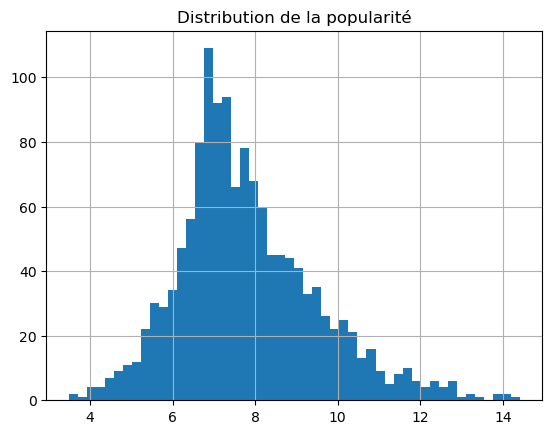

0    you dream you 🥹 #davosklosters #skiing #mounta...
1    already missing this again 🥹 #spenglercup #dav...
2    how??!!!🥹🥹 #davosklosters #skiing #ski #season...
3    We're back on snow!🥹🎿 #davosklosters #seasonop...
4    Somebody send help, pls. 🥶 #davos #firstsnow #...
5    bald bald 🥹🫰🏽🎿 #davosklosters #sportsunlimited...
6    Holy fckn airball 😎✌🏽  #davosklosters #holyfck...
7    Saisonende? Was?!🥹 #davosklosters #seasonend #...
8    Willkommen zurück im Winter!🥹🎿 Wer hat auch no...
9    März, wir lieben dich!🥹🫶🏽 #davosklosters #skii...
Name: description, dtype: object


In [8]:
print(df["popularity"].value_counts())
df["popularity"].hist(bins=50)
plt.title("Distribution de la popularité")
plt.show()

# --- 3. Aperçu des colonnes textuelles ---
print(df["description"].head(10))  # adapter le nom de colonne réel


In [ ]:
df["duration_bin"] = pd.cut(df["video_duration"], 
                             bins=[0, 5, 6, 8, 10, 12, 15], 
                             labels=["<5s", "5-6s", "6-8s", "8-10s", "10-12s", ">12s"])

# Créer une feature booléenne : est-ce une vidéo "courte" (<15s) ?
df["is_short"] = (df["video_duration"] < 5).astype(int)



In [12]:
# 1. Regrouper les "sons originaux" multilingues en une seule feature
original_keywords = ["original sound", "son original", "originalton", 
                     "son original ", "original audio"]  # attention aux espaces

df["is_original_sound"] = df["track"].str.lower().str.strip().isin(
    [k.lower() for k in original_keywords]
).astype(int)

# 2. A-t-il une musique ajoutée (= pas un son original) ?
df["has_added_music"] = (
    (df["track"].notna()) & (df["is_original_sound"] == 0)
).astype(int)

# 3. Fréquence de la musique (les musiques trending reviennent souvent)
music_freq = df["track"].value_counts().to_dict()
df["track_frequency"] = df["track"].map(music_freq).fillna(0)

# Une musique utilisée par beaucoup de créateurs = tendance = signal fort !
df["is_trending_sound"] = (df["track_frequency"] >= 5).astype(int)

# 4. Gérer les manquants
df["track_missing"] = df["track"].isna().astype(int)
df["track"] = df["track"].fillna("unknown")

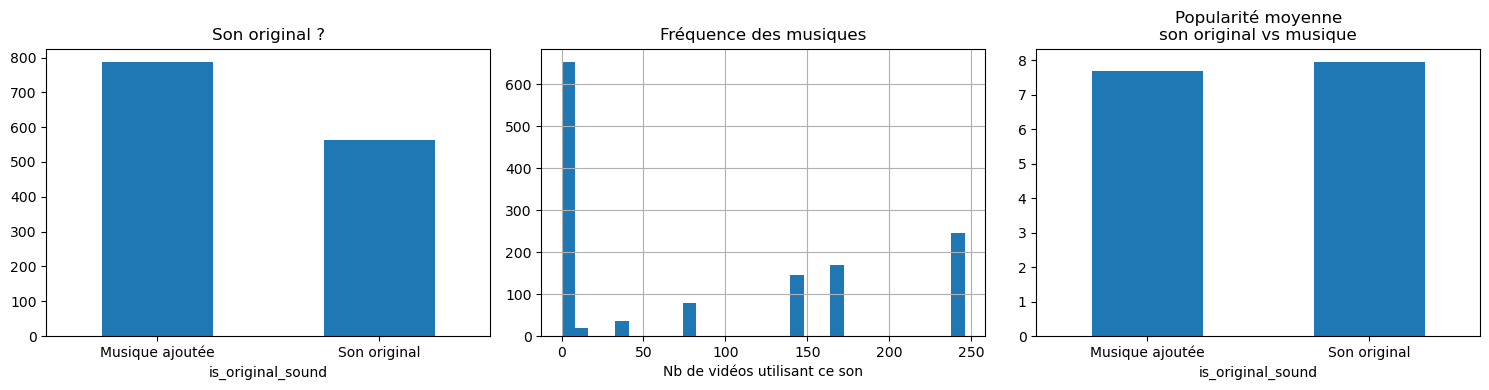

In [13]:
# Distribution des catégories créées
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1. Son original vs musique ajoutée
df["is_original_sound"].value_counts().plot(kind="bar", ax=axes[0])
axes[0].set_title("Son original ?")
axes[0].set_xticklabels(["Musique ajoutée", "Son original"], rotation=0)

# 2. Distribution de la fréquence des musiques
df["track_frequency"].hist(bins=30, ax=axes[1])
axes[1].set_title("Fréquence des musiques")
axes[1].set_xlabel("Nb de vidéos utilisant ce son")

# 3. Popularité moyenne selon le type de son
df.groupby("is_original_sound")["popularity"].mean().plot(kind="bar", ax=axes[2])
axes[2].set_title("Popularité moyenne\nson original vs musique")
axes[2].set_xticklabels(["Musique ajoutée", "Son original"], rotation=0)

plt.tight_layout()
plt.show()

# SON

In [7]:
pip install tensorflow tensorflow-hub librosa soundfile

Note: you may need to restart the kernel to use updated packages.


In [8]:
import subprocess
import os

def extract_audio_from_video(video_path, output_path="temp_audio.wav"):
    """
    Extrait l'audio d'un fichier MP4 et le sauvegarde en WAV.
    Utilise ffmpeg (doit être installé sur le système).
    """
    command = [
        "ffmpeg",
        "-i", str(video_path),   # fichier d'entrée
        "-ar", "16000",          # resample à 16kHz (requis par YAMNet)
        "-ac", "1",              # mono (1 canal)
        "-f", "wav",             # format WAV
        output_path,
        "-y",                    # écraser si le fichier existe déjà
        "-loglevel", "quiet"     # pas de logs ffmpeg
    ]
    subprocess.run(command)
    return output_path

# Test sur une vidéo
audio_path = extract_audio_from_video("/home/jmaubian/SDD/Hackathon/videos_mp4/downloads/USER_alpedhuez/VIDEO_6814175723704683782.mp4")
print(f"Audio extrait : {audio_path}")

Audio extrait : temp_audio.wav


In [9]:
import tensorflow as tf
import tensorflow_hub as hub
import numpy as np
import soundfile as sf

2026-03-03 09:14:21.100461: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [16]:
import tensorflow as tf
import tensorflow_hub as hub
import numpy as np
import soundfile as sf

# Téléchargement automatique du modèle (environ 17MB, une seule fois)
print("Chargement de YAMNet...")
yamnet_model = hub.load("https://tfhub.dev/google/yamnet/1")
print("Modèle chargé !")

# Charger les noms des 521 classes
class_map_path = yamnet_model.class_map_path().numpy().decode("utf-8")
class_names = [line.split(",")[2].strip() 
               for line in tf.io.gfile.GFile(class_map_path).readlines()[1:]]

print(f"Nombre de classes : {len(class_names)}")
print(f"Exemples : {class_names[:5]}")

# Trouver les indices des classes qui nous intéressent
music_idx   = class_names.index("Music")
speech_idx  = class_names.index("Speech")
wind_idx    = class_names.index("Wind")

print(f"Index Music: {music_idx}, Speech: {speech_idx}, Wind: {wind_idx}")

2026-03-02 10:57:04.868735: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Chargement de YAMNet...


2026-03-02 10:57:25.150178: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Modèle chargé !
Nombre de classes : 521
Exemples : ['Speech', '"Child speech', 'Conversation', '"Narration', 'Babbling']
Index Music: 132, Speech: 0, Wind: 277


In [18]:
def classify_audio(audio_path):
    """
    Passe l'audio dans YAMNet et retourne les probabilités moyennes
    pour chaque classe sur toute la durée de la vidéo.
    """
    # Charger le fichier audio
    waveform, sample_rate = sf.read(audio_path, dtype="float32")
    
    # YAMNet découpe automatiquement en fenêtres de 0.96s
    # scores : (nb_fenêtres, 521) — une proba par classe par fenêtre
    scores, embeddings, spectrogram = yamnet_model(waveform)
    
    # Moyenne des scores sur toutes les fenêtres temporelles
    mean_scores = scores.numpy().mean(axis=0)  # shape : (521,)
    
    return mean_scores, class_names

# Test
mean_scores, class_names = classify_audio("temp_audio.wav")

# Afficher le top 5 des classes détectées
top5_idx = mean_scores.argsort()[-5:][::-1]
print("Top 5 sons détectés :")
for idx in top5_idx:
    print(f"  {class_names[idx]:<30} {mean_scores[idx]:.3f}")


Top 5 sons détectés :
  Music                          0.591
  Vehicle                        0.095
  Motor vehicle (road)           0.027
  Car                            0.026
  "Boat                          0.019


2026-03-02 11:01:22.038253: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 10616832 exceeds 10% of free system memory.


In [19]:
def extract_music_features(video_path):
    """
    Pipeline complet : vidéo MP4 → features musique.
    """
    try:
        # 1. Extraire l'audio
        audio_path = extract_audio_from_video(video_path, "temp_audio.wav")
        
        # 2. Classifier avec YAMNet
        mean_scores, class_names = classify_audio(audio_path)
        
        # 3. Récupérer les scores des classes importantes
        features = {
            "yamnet_music_score":   float(mean_scores[class_names.index("Music")]),
            "yamnet_speech_score":  float(mean_scores[class_names.index("Speech")]),
            "yamnet_wind_score":    float(mean_scores[class_names.index("Wind")]),
            "yamnet_crowd_score":   float(mean_scores[class_names.index("Crowd")]),
            
            # Feature binaire : est-ce de la musique ?
            # Seuil de 0.3 = à ajuster selon tes résultats
            "is_music":  int(mean_scores[class_names.index("Music")] > 0.3),
            "is_speech": int(mean_scores[class_names.index("Speech")] > 0.3),
            
            # Classe dominante
            "dominant_sound": class_names[mean_scores.argmax()],
        }
        
        # Nettoyer le fichier temporaire
        os.remove(audio_path)
        
        return features
    
    except Exception as e:
        print(f"Erreur sur {video_path} : {e}")
        return {"is_music": -1, "yamnet_music_score": np.nan}

In [10]:
from pathlib import Path
import pandas as pd
from tqdm import tqdm

In [ ]:
from pathlib import Path
import pandas as pd
from tqdm import tqdm  

X_train=pd.read_csv("/home/jmaubian/SDD/Hackathon/X_train.csv",sep=';')
X_test=pd.read_csv("/home/jmaubian/SDD/Hackathon/X_test.csv",sep=';')

BASE_PATH = Path("/home/jmaubian/SDD/Hackathon/videos_mp4")

results = []

for _, row in tqdm(df.iterrows(), total=len(df)):
    video_path = BASE_PATH / row["filepath"]
    
    if video_path.exists():
        feats = extract_music_features(video_path)
        feats["ID"] = row["ID"]
    else:
        feats = {"ID": row["ID"], "is_music": -1, "yamnet_music_score": np.nan}
    results.append(feats)

music_df = pd.DataFrame(results)
df = df.merge(music_df, on="ID", how="left")
music_df.to_csv("features_yamnet.csv", index=False)
print("Features sauvegardées")

  0%|          | 0/1348 [00:00<?, ?it/s]

2026-03-02 11:19:40.163522: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 10616832 exceeds 10% of free system memory.
100%|██████████| 1348/1348 [06:18<00:00,  3.56it/s]


Features sauvegardées ✅


In [33]:
df_X = pd.concat([X_train, X_test], ignore_index=True)

from pathlib import Path
import pandas as pd
from tqdm import tqdm 

X_train=pd.read_csv("/home/jmaubian/SDD/Hackathon/X_train.csv",sep=';')
X_test=pd.read_csv("/home/jmaubian/SDD/Hackathon/X_test.csv",sep=';')

BASE_PATH = Path("/home/jmaubian/SDD/Hackathon/videos_mp4")

results = []

for _, row in tqdm(df_X.iterrows(), total=len(df_X)):
    video_path = BASE_PATH / row["filepath"]
    
    if video_path.exists():
        feats = extract_music_features(video_path)
        feats["id"] = row["id"]
    else:
        feats = {"id": row["id"], "is_music": -1, "yamnet_music_score": np.nan}
    results.append(feats)

music_df = pd.DataFrame(results)
df_X = df_X.merge(music_df, on="id", how="left")
music_df.to_csv("features_yamnet_X.csv", index=False)
print("Features sauvegardées")

100%|██████████| 1686/1686 [16:26<00:00,  1.71it/s]


Features sauvegardées


# LUMINOSITE / QUALITE VIDEO

In [11]:
pip install opencv-python torch torchvision numpy scipy tqdm

Note: you may need to restart the kernel to use updated packages.


In [12]:
import cv2
import numpy as np

def extract_frames(video_path, num_frames=16):
    cap = cv2.VideoCapture(video_path)
    
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total_frames == 0:
        return []
    
    frame_indices = np.linspace(0, total_frames - 1, num_frames).astype(int)
    
    frames = []
    for idx in frame_indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()
        if ret:
            frames.append(frame)
    
    cap.release()
    return frames

from scipy.stats import skew

def compute_brightness_contrast(frames):
    brightness_values = []
    
    for frame in frames:
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        brightness_values.append(gray.mean())
    
    brightness_values = np.array(brightness_values)
    
    features = {
        "brightness_mean": brightness_values.mean(),
        "brightness_std": brightness_values.std(),
        "brightness_min": brightness_values.min(),
        "brightness_max": brightness_values.max(),
        "brightness_skew": skew(brightness_values)
    }
    
    return features

def extract_visual_basic_features(video_path):
    frames = extract_frames(video_path)
    if len(frames) == 0:
        return None
    
    return compute_brightness_contrast(frames)

In [14]:
BASE_PATH = Path("/home/jmaubian/SDD/Hackathon/videos_mp4")

test_path = BASE_PATH / df.iloc[0]["filepath"]
feats = extract_visual_basic_features(str(test_path))
print(feats)

{'brightness_mean': np.float64(161.2547817804784), 'brightness_std': np.float64(10.120299688736134), 'brightness_min': np.float64(140.81067756558642), 'brightness_max': np.float64(176.41972415123456), 'brightness_skew': np.float64(-0.6064271273916519)}


In [15]:
BASE_PATH = Path("/home/jmaubian/SDD/Hackathon/videos_mp4")

visual_results = []

for _, row in tqdm(df.iterrows(), total=len(df)):
    video_path = BASE_PATH / row["filepath"]
    
    if video_path.exists():
        feats = extract_visual_basic_features(str(video_path))  # cv2 attend un string
        if feats is not None:
            feats["id"] = row["id"]
        else:
            feats = {"id": row["id"]}
    else:
        feats = {"id": row["id"]}
    
    visual_results.append(feats)

visual_df = pd.DataFrame(visual_results)
df = df.merge(visual_df, on="id", how="left")

visual_df.to_csv("features_visual1.csv", index=False)
print("Features visuelles sauvegardées")

100%|██████████| 1348/1348 [3:20:27<00:00,  8.92s/it]     


Features visuelles sauvegardées


In [1]:
import torch
import torchvision.models as models
import torchvision.transforms as transforms

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

resnet = models.resnet50(pretrained=True)
resnet = torch.nn.Sequential(*list(resnet.children())[:-1])  # remove FC
resnet.eval()
resnet.to(device)

/home/jmaubian/anaconda3/envs/data/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/jmaubian/anaconda3/envs/data/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Sequential(
  (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (4): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)


In [2]:
transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

def extract_frame_embedding(frame):
    img = transform(frame).unsqueeze(0).to(device)
    
    with torch.no_grad():
        embedding = resnet(img)
    
    return embedding.squeeze().cpu().numpy()

def extract_video_embedding(video_path, num_frames=16):
    frames = extract_frames(video_path, num_frames)
    
    if len(frames) == 0:
        return None
    
    embeddings = []
    
    for frame in frames:
        emb = extract_frame_embedding(frame)
        embeddings.append(emb)
    
    embeddings = np.array(embeddings)
    
    # moyenne temporelle
    video_embedding = embeddings.mean(axis=0)
    
    return video_embedding

In [3]:
def compute_visual_score(embedding):
    return np.linalg.norm(embedding)

In [4]:
def extract_all_visual_features(video_path):
    basic_features = extract_visual_basic_features(video_path)
    embedding = extract_video_embedding(video_path)
    
    if embedding is None:
        return None
    
    visual_score = np.linalg.norm(embedding)
    
    features = basic_features
    features["visual_score"] = visual_score
    
    return features, embedding

In [6]:
from pathlib import Path
import pandas as pd
from tqdm import tqdm 

In [13]:
BASE_PATH = Path("/home/jmaubian/SDD/Hackathon/videos_mp4")

X_train=pd.read_csv("/home/jmaubian/SDD/Hackathon/X_train.csv",sep=';')
X_test=pd.read_csv("/home/jmaubian/SDD/Hackathon/X_test.csv",sep=';')
df_X = pd.concat([X_train, X_test], ignore_index=True)

all_visual_results = []
all_embeddings = {}  # on stocke les embeddings séparément car ce sont des vecteurs lourds

for _, row in tqdm(df_X.iterrows(), total=len(df_X)):
    video_path = str(BASE_PATH / row["filepath"])  # cv2 et torch attendent un string
    
    try:
        result = extract_all_visual_features(video_path)
        
        if result is not None:
            feats, embedding = result  # déballage du tuple
            feats["id"] = row["id"]
            all_embeddings[row["id"]] = embedding  # stocker le vecteur (512 dims)
        else:
            feats = {"id": row["id"]}
    
    except Exception as e:
        print(f"Erreur sur {row['id']} : {e}")
        feats = {"id": row["id"]}
    
    all_visual_results.append(feats)

# --- Créer le DataFrame des features simples ---
visual_df = pd.DataFrame(all_visual_results)
df = df_X.merge(visual_df, on="id", how="left")

# --- Sauvegarder les features simples ---
visual_df.to_csv("features_visual2.csv", index=False)
print(f"Features visuelles sauvegardées ({len(visual_df)} vidéos)")

# --- Sauvegarder les embeddings séparément (numpy) ---
# Les embeddings sont des vecteurs de 512 dimensions → trop lourds pour un CSV
import pickle
with open("embeddings_video.pkl", "wb") as f:
    pickle.dump(all_embeddings, f)
print(f"Embeddings sauvegardés  ({len(all_embeddings)} vidéos)")

100%|██████████| 1686/1686 [6:06:58<00:00, 13.06s/it]  


Features visuelles sauvegardées (1686 vidéos)
Embeddings sauvegardés  (1686 vidéos)


In [ ]:
import pickle
with open("embeddings_video.pkl", "rb") as f:
    all_embeddings = pickle.load(f)

# Convertir en DataFrame si besoin pour le modèle
emb_df = pd.DataFrame(
    {vid_id: emb for vid_id, emb in all_embeddings.items()}
).T.reset_index()
emb_df.columns = ["ID"] + [f"emb_{i}" for i in range(512)]

df = df.merge(emb_df, on="ID", how="left")

# TEXTE SUR IMAGE

In [ ]:
#pip install opencv-python easyocr scikit-learn xgboost sentence-transformers

  Using cached sentence_transformers-5.2.3-py3-none-any.whl.metadata (16 kB)
Using cached sentence_transformers-5.2.3-py3-none-any.whl (494 kB)
Note: you may need to restart the kernel to use updated packages.
